# GatedFusion Weight Analysis
Checkpoint: `runs/protected/three_seeds/20260301-205342__ctmp_gin__bs=256__lr=2.00e-04__seed=1/checkpoints/best.pt`

In [1]:
import os
import sys

# Project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import yaml
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

from src.data_processing.tensor_dataset import TEDSTensorDataset
from src.data_processing.data_utils import train_test_split_stratified
from src.models.factory import build_model, build_edge
from src.utils.device_set import device_set

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/jeong-yunseong/Documents/programming/Phase_2_public


/opt/miniconda3/envs/pyg_2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Config & Paths

In [2]:
RUN_DIR = os.path.join(
    PROJECT_ROOT,
    "runs", "protected", "three_seeds",
    "20260301-205342__ctmp_gin__bs=256__lr=2.00e-04__seed=1"
)
CKPT_PATH = os.path.join(RUN_DIR, "checkpoints", "best.pt")
CFG_PATH  = os.path.join(RUN_DIR, "config.final.yaml")
DATA_ROOT = os.path.join(PROJECT_ROOT, "src", "data")

assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"
assert os.path.exists(CFG_PATH),  f"Config not found: {CFG_PATH}"

with open(CFG_PATH) as f:
    cfg = yaml.safe_load(f)

print(yaml.dump(cfg, default_flow_style=False))

cv:
  cv: true
device: null
edge:
  edge_cached: true
  is_mi_based: true
  n_neighbors: 7
  pruning_ratio: 0.7
  return_edge_attr: false
  threshold: 0.01
  top_k: 9
model:
  name: ctmp_gin
  params:
    dropout_p: 0.018503542107251567
    embedding_dim: 16
    gate_hidden_ch: 128
    gin_1_layers: 3
    gin_2_layers: 3
    gin_hidden_channel: 96
    gin_hidden_channel_2: 96
    los_embedding_dim: 4
    train_eps: false
train:
  batch_size: 256
  binary: true
  cv: false
  decision_threshold: 0.5
  early_stopping_patience: 10
  epochs: 100
  ig_label: false
  learning_rate: 0.0002000054566973331
  lr_scheduler_patience: 5
  n_folds: 5
  num_workers: 4
  optimizer: adamw
  seed: 1
  test_ratio: 0.15
  train_ratio: 0.7
  val_ratio: 0.15
  weight_decay: 1.0482209742775742e-05



## 2. Dataset & Split

In [3]:
seed       = cfg["train"]["seed"]          # 1
batch_size = cfg["train"]["batch_size"]    # 256
split_ratio = [
    cfg["train"]["train_ratio"],
    cfg["train"]["val_ratio"],
    cfg["train"]["test_ratio"],
]

dataset = TEDSTensorDataset(
    root=DATA_ROOT,
    binary=cfg["train"]["binary"],
    ig_label=cfg["train"].get("ig_label", False),
    remove_los=True,
)

# Replicate the same stratified split used during training (same seed)
train_loader, val_loader, test_loader, idx = train_test_split_stratified(
    dataset=dataset,
    batch_size=batch_size,
    ratio=split_ratio,
    seed=seed,
    num_workers=0,
)
train_idx, val_idx, test_idx = idx
train_df = dataset.processed_df.iloc[train_idx]

print(f"num_classes: {dataset.num_classes}")

Train Set Size: 975896
Valid Set Size: 209119
Test Set Size: 209123
num_classes: 2


## 3. Build Model & Load Checkpoint

In [4]:
device = device_set(cfg["device"])

model_params = dict(cfg["model"]["params"])
model_params["col_info"]    = dataset.col_info
model_params["num_classes"] = dataset.num_classes
model_params["device"]      = device

model = build_model(model_name=cfg["model"]["name"], **model_params)

ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
model.to(device)
print("Checkpoint loaded. Epoch:", ckpt.get("epoch", "N/A"))

Using device: mps
Using manually specified device: mps
Checkpoint loaded. Epoch: 31


## 4. Build Edge Index

In [5]:
num_nodes = len(dataset.col_info[2])  # len(ad_col_index)

edge_index = build_edge(
    model_name=cfg["model"]["name"],
    root=DATA_ROOT,
    seed=seed,
    train_df=train_df,
    num_nodes=num_nodes,
    batch_size=batch_size,
    **cfg.get("edge", {})
)
edge_index = edge_index.to(device)
print("edge_index shape:", edge_index.shape)

Buliding Edge Index Based on Mutual Information
Loading cached file...
edge_index shape: torch.Size([2, 398848])


## 5. Collect GatedFusion Weights via Forward Hook

In [6]:
# GatedFusion.forward returns (fused, w, logits)
# w shape: [B, 3]  ->  columns = [w_ad, w_dis, w_merged]

all_w      = []  # fusion weights
all_labels = []  # ground-truth labels
all_preds  = []  # predicted probabilities

def _hook(module, input, output):
    """Capture the softmax weight tensor w from GatedFusion output."""
    _, w, _ = output          # (fused, w, logits)
    all_w.append(w.detach().cpu())

hook_handle = model.gated_fusion.register_forward_hook(_hook)

# Use the full dataset loader (no drop_last so we catch every sample)
full_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                         num_workers=0, drop_last=True)

with torch.no_grad():
    for x_batch, y_batch, los_batch in tqdm(full_loader, desc="Collecting weights"):
        x_batch   = x_batch.to(device)
        los_batch = los_batch.to(device)
        y_batch   = y_batch.to(device)

        logits = model(x_batch, los_batch, edge_index, device=device)
        probs  = torch.sigmoid(logits.squeeze(1)).cpu()

        all_labels.append(y_batch.cpu())
        all_preds.append(probs)

hook_handle.remove()

W      = torch.cat(all_w,      dim=0).numpy()   # (N, 3)
labels = torch.cat(all_labels, dim=0).numpy()   # (N,)
preds  = torch.cat(all_preds,  dim=0).numpy()   # (N,)

print(f"W shape: {W.shape}, labels: {labels.shape}")

W shape: (1393920, 3), labels: (1393920,)


## 6. Summary Statistics

In [34]:
df_w = pd.DataFrame(W, columns=["w_ad", "w_dis", "w_merged"])
df_w["label"] = labels
df_w["pred"]  = preds

print("=== Overall mean weights ===")
print(df_w[["w_ad", "w_dis", "w_merged"]].mean().to_string())
print()
print("=== Mean weights by class ===")
print(df_w.groupby("label")[["w_ad", "w_dis", "w_merged"]].mean().to_string())
print()
print("=== Std weights by class ===")
print(df_w.groupby("label")[["w_ad", "w_dis", "w_merged"]].std().to_string())


ValueError: Length of values (7) does not match length of index (1393920)

In [26]:
df_w.to_csv("Gated_Fusion_weight_seed_1.csv")

## 7. Visualisation

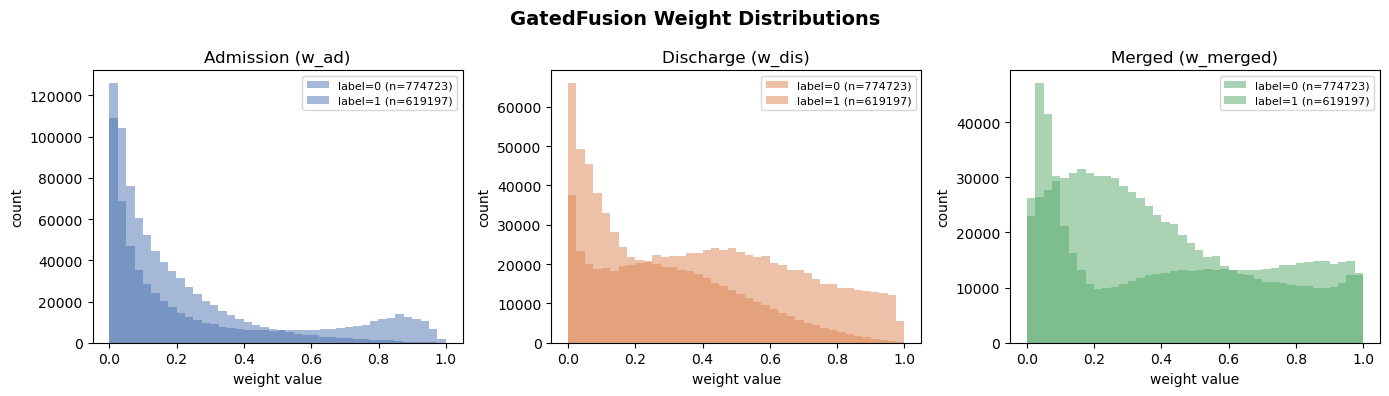

In [8]:
COMPONENT_NAMES = ["Admission (w_ad)", "Discharge (w_dis)", "Merged (w_merged)"]
COLORS = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
fig.suptitle("GatedFusion Weight Distributions", fontsize=14, fontweight="bold")

for i, (ax, name, color) in enumerate(zip(axes, COMPONENT_NAMES, COLORS)):
    col = ["w_ad", "w_dis", "w_merged"][i]
    for cls_val, ls in zip([0, 1], ["--", "-"]):
        subset = df_w.loc[df_w["label"] == cls_val, col]
        ax.hist(subset, bins=40, alpha=0.5, color=color, linestyle=ls,
                label=f"label={int(cls_val)} (n={len(subset)})")
    ax.set_title(name)
    ax.set_xlabel("weight value")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

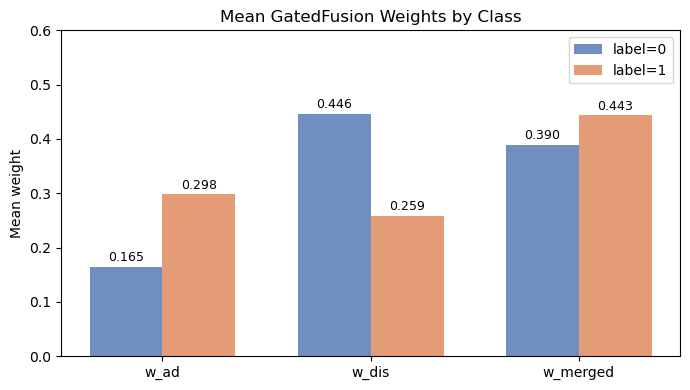

In [9]:
# Bar chart: mean weight per component, split by class
mean_by_class = df_w.groupby("label")[["w_ad", "w_dis", "w_merged"]].mean()

x = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars0 = ax.bar(x - width/2, mean_by_class.loc[0], width, label="label=0", color="#4C72B0", alpha=0.8)
bars1 = ax.bar(x + width/2, mean_by_class.loc[1], width, label="label=1", color="#DD8452", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(["w_ad", "w_dis", "w_merged"])
ax.set_ylabel("Mean weight")
ax.set_title("Mean GatedFusion Weights by Class")
ax.legend()
ax.set_ylim(0, 0.6)

for bar in bars0:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [10]:
df_w

,w_ad,w_dis,w_merged,label,pred
0,0.197252,0.570065,0.232683,0,0.184726
1,0.950628,0.023891,0.025481,0,0.253837
2,0.257958,0.577605,0.164438,0,0.294031
3,0.027725,0.341697,0.630578,0,0.625403
4,0.114644,0.288243,0.597114,0,0.732187
...,...,...,...,...,...
1393915,0.107406,0.502378,0.390216,0,0.151475
1393916,0.235405,0.587534,0.177061,0,0.038492
1393917,0.532636,0.379189,0.088175,0,0.464366
1393918,0.411195,0.289344,0.299461,0,0.175352


In [ ]:
raw_df = pd.read_csv(os.path.join(DATA_ROOT, 'raw', 'TEDS_Discharge.csv'))
raw_df

In [19]:
los = raw_df['LOS'][:1393920].copy()
los

0          36
1           1
2          34
3          36
4          37
           ..
1393915    30
1393916    27
1393917     4
1393918    22
1393919    35
Name: LOS, Length: 1393920, dtype: int64

In [21]:
df_w_los = df_w.copy()
df_w_los["LOS"] = los
df_w_los

,w_ad,w_dis,w_merged,label,pred,LOS
0,0.197252,0.570065,0.232683,0,0.184726,36
1,0.950628,0.023891,0.025481,0,0.253837,1
2,0.257958,0.577605,0.164438,0,0.294031,34
3,0.027725,0.341697,0.630578,0,0.625403,36
4,0.114644,0.288243,0.597114,0,0.732187,37
...,...,...,...,...,...,...
1393915,0.107406,0.502378,0.390216,0,0.151475,30
1393916,0.235405,0.587534,0.177061,0,0.038492,27
1393917,0.532636,0.379189,0.088175,0,0.464366,4
1393918,0.411195,0.289344,0.299461,0,0.175352,22


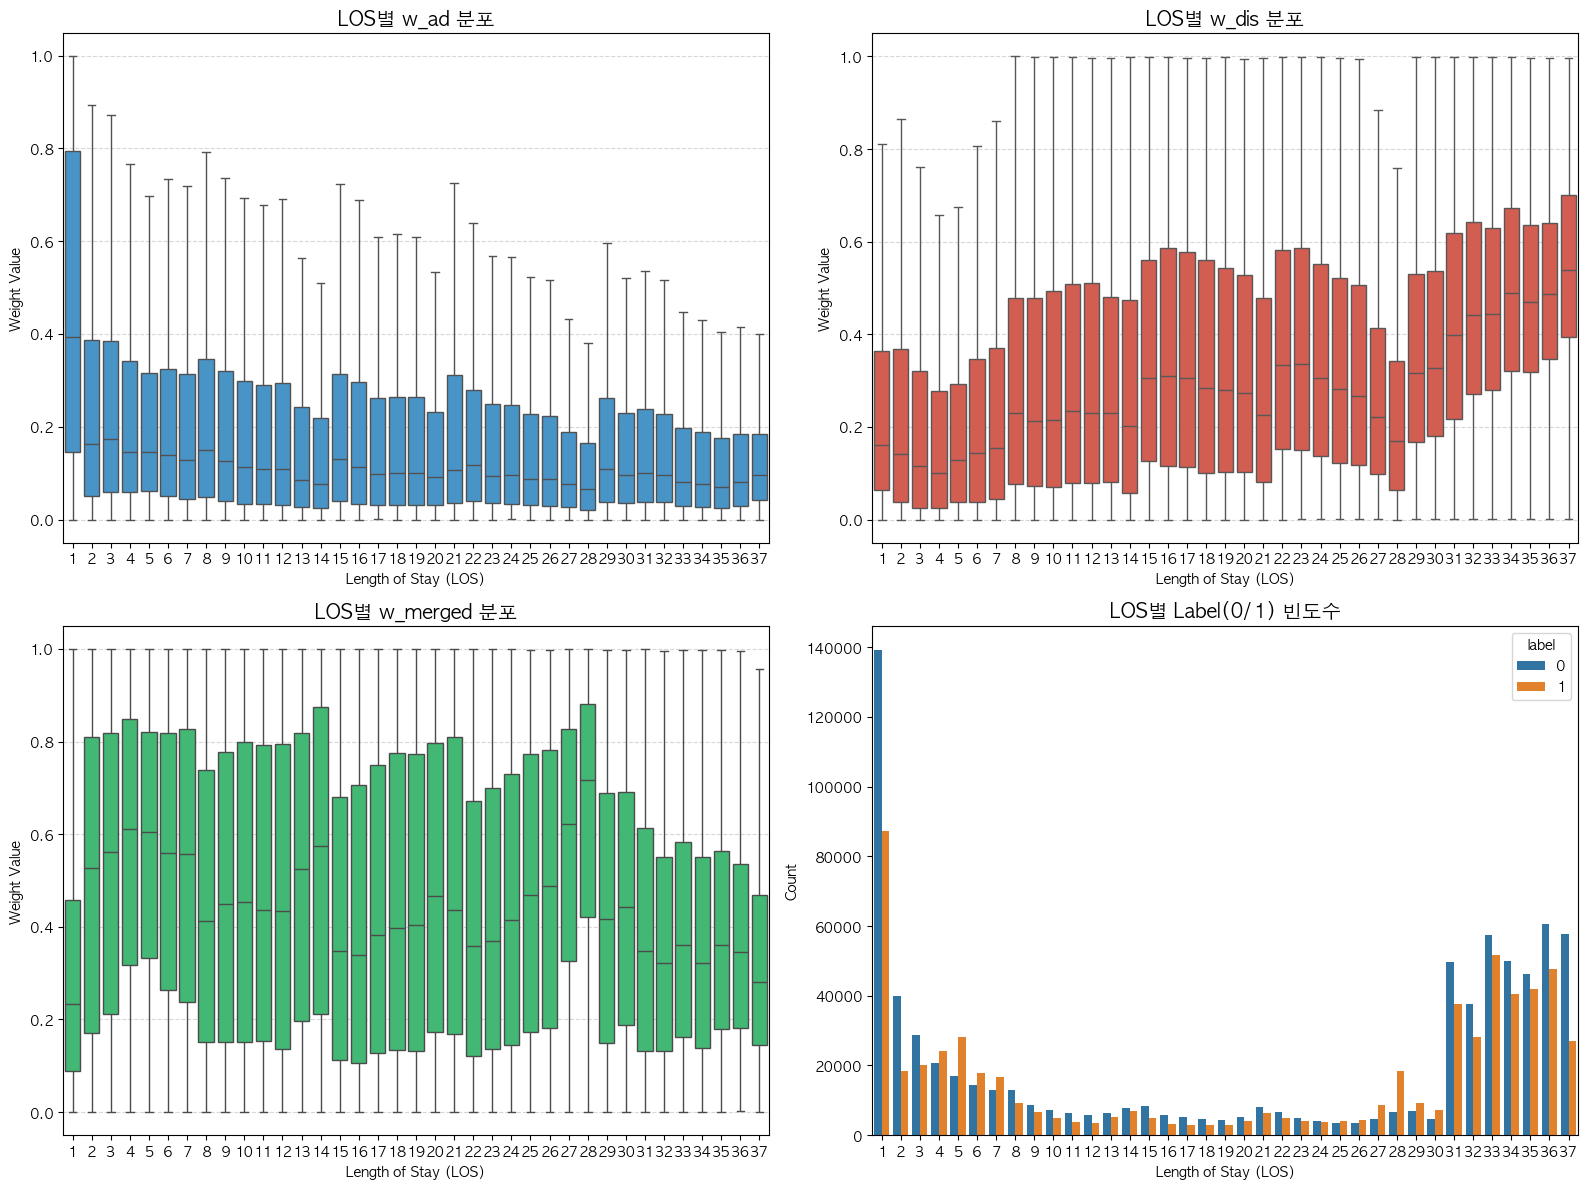

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Mac: AppleGothic, Windows: Malgun Gothic)
plt.rcParams['font.family'] = 'AppleGothic' 
plt.rcParams['axes.unicode_minus'] = False

# 시각화할 변수 리스트
features = ['w_ad', 'w_dis', 'w_merged']
colors = ['#3498db', '#e74c3c', '#2ecc71'] # 각 변수별 색상 구분

# 2x2 레이아웃 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # 2차원 배열을 1차원으로 변환하여 반복문 사용 용이하게 함

# 1~3. w_ad, w_dis, w_merged 각각 그리기
for i, col in enumerate(features):
    sns.boxplot(data=df_w_los, x='LOS', y=col, ax=axes[i], color=colors[i], showfliers=False)
    axes[i].set_title(f'LOS별 {col} 분포', fontsize=14)
    axes[i].set_xlabel('Length of Stay (LOS)')
    axes[i].set_ylabel('Weight Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# 4. label 분포 그리기
sns.countplot(data=df_w_los, x='LOS', hue='label', ax=axes[3])
axes[3].set_title('LOS별 Label(0/1) 빈도수', fontsize=14)
axes[3].set_xlabel('Length of Stay (LOS)')
axes[3].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
df_w_los.to_csv("gated_fustion_w_los_seed_1.csv")

In [33]:
# LOS별로 그룹화하여 요약 통계량 산출
# unstack()을 사용하면 보기 편한 형태로 펼쳐집니다.
df_summary = df_w_los.groupby('LOS')[['w_ad', 'w_dis', 'w_merged', 'label']].describe()

# 결과 확인
display(df_summary)

df_summary.to_csv("gated_fustion_w_los_seed_1.csv")

w_ad                                                              \
        count      mean       std       min       25%       50%       75%   
LOS                                                                         
1    226406.0  0.449636  0.323527  0.000020  0.144576  0.392539  0.793287   
2     58361.0  0.257899  0.260516  0.000011  0.049923  0.162865  0.387251   
3     49086.0  0.258364  0.250871  0.000009  0.059923  0.172574  0.384407   
4     44711.0  0.236857  0.239042  0.000009  0.059651  0.146130  0.342652   
5     45216.0  0.230520  0.233970  0.000078  0.062528  0.145894  0.316110   
6     32124.0  0.234739  0.251064  0.000053  0.050531  0.138928  0.323782   
7     29606.0  0.228226  0.252151  0.000018  0.044395  0.127708  0.314615   
8     22190.0  0.244725  0.256631  0.000024  0.048379  0.149789  0.346083   
9     15172.0  0.230904  0.258227  0.000050  0.040833  0.127085  0.319383   
10    12287.0  0.215919  0.250824  0.000084  0.034293  0.112446  0.297744   
11    10162.0  0.212094  0.247641  0.000055  0.033079  0.109846  0.290938   
12     9179.0  0.214313  0.252327  0.000035  0.031897  0.108139  0.295316   
13    11667.0  0.182592  0.227632  0.000081  0.027565  0.085890  0.241964   
14    14560.0  0.169872  0.220191  0.000017  0.024137  0.076426  0.218241   
15    13310.0  0.229244  0.253281  0.000102  0.039840  0.130928  0.313406   
16     9220.0  0.216805  0.250229  0.000059  0.034540  0.113328  0.296510   
17     8099.0  0.196469  0.236079  0.000186  0.030834  0.098336  0.262481   
18     7555.0  0.198493  0.237095  0.000065  0.030803  0.099785  0.264866   
19     7523.0  0.200569  0.239439  0.000049  0.032127  0.101017  0.263371   
20     9228.0  0.178338  0.215508  0.000023  0.031682  0.091937  0.232832   
21    14665.0  0.216877  0.245212  0.000039  0.034735  0.107591  0.310864   
22    11617.0  0.208860  0.236507  0.000090  0.039415  0.116766  0.279634   
23     8869.0  0.193049  0.231821  0.000128  0.035157  0.093487  0.248425   
24     7926.0  0.190799  0.229043  0.000246  0.033144  0.097028  0.246556   
25     7654.0  0.177692  0.216830  0.000045  0.030960  0.088072  0.228182   
26     7938.0  0.177210  0.221021  0.000098  0.028926  0.087287  0.224246   
27    13118.0  0.145924  0.181798  0.000060  0.027114  0.077470  0.188873   
28    24876.0  0.126853  0.165305  0.000074  0.021579  0.065627  0.164810   
29    16034.0  0.200360  0.228752  0.000121  0.037071  0.108131  0.261101   
30    11797.0  0.176280  0.204443  0.000133  0.035586  0.096894  0.230374   
31    87508.0  0.182468  0.209256  0.000034  0.037821  0.100890  0.237319   
32    65679.0  0.175048  0.200263  0.000025  0.036939  0.095647  0.228285   
33   108933.0  0.150533  0.176449  0.000029  0.030206  0.080962  0.197432   
34    90422.0  0.137426  0.158492  0.000024  0.026932  0.076441  0.188010   
35    88039.0  0.131266  0.156997  0.000024  0.024271  0.069565  0.175957   
36   108383.0  0.132519  0.145581  0.000014  0.028764  0.080465  0.183514   
37    84800.0  0.133093  0.124806  0.000035  0.041721  0.095030  0.185152   

                  w_dis            ...  w_merged               label  \
          max     count      mean  ...       75%       max     count   
LOS                                ...                                 
1    0.997902  226406.0  0.240372  ...  0.458266  0.999874  226406.0   
2    0.998186   58361.0  0.238701  ...  0.810018  0.999620   58361.0   
3    0.999656   49086.0  0.216649  ...  0.818949  0.999739   49086.0   
4    0.999398   44711.0  0.195494  ...  0.848375  0.999680   44711.0   
5    0.999136   45216.0  0.204992  ...  0.821651  0.999799   45216.0   
6    0.999187   32124.0  0.230583  ...  0.817594  0.999827   32124.0   
7    0.998531   29606.0  0.241832  ...  0.826685  0.999905   29606.0   
8    0.998564   22190.0  0.305396  ...  0.738785  0.999571   22190.0   
9    0.997833   15172.0  0.299902  ...  0.776635  0.999669   15172.0   
10   0.996366   12287.0  0.305846  ...  0.799731  0.999619   122